In [35]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [ ]:
t1_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t1.slp'
t1_labels = sleap.load_file(t1_labels_path)
print(t1_labels)
t1_all_tracked_points = get_all_tracked_points(t1_labels, reorder=True)
t1_all_tracked_points.shape

In [ ]:
c3_simplemax_track_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking.slp'
c3_simplemax_track = sleap.load_file(c3_simplemax_track_path)
c3_simplemax_tracked_points = get_all_tracked_points(c3_simplemax_track, reorder=True)
c3_simplemax_tracked_points.shape

In [4]:
t1_labels

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)

In [11]:
# c3_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/predictions/c3_predictions.slp.250120_125305.predictions.slp'
# c3_labels = sleap.load_file(c3_labels_path)
# t1_all_tracked_points = get_all_tracked_points(c3_labels, reorder=True)

In [3]:
t1_all_tracked_points.shape

(827, 16, 2)

1. Find swapped IDs: when expanded (radius max), a point should be connected to its 2 closest neighbors; if not, considered as swapped
- ID the center 
- compute the radius for each point 
- if all point radius at least 50% max, ID as expanded

2. Correct (swap)

3. Propagate in time in both directions

## Identify frames where the jellyfish is expanded

### get center position

In [5]:
frame1 = t1_labels.video.get_frame(1)

In [6]:
center_pos = np.array([91, 77])

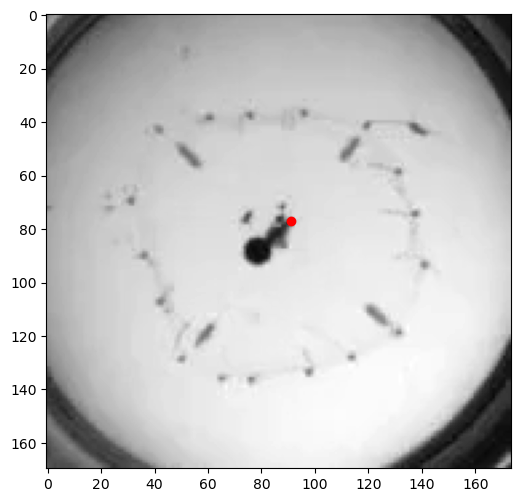

In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(frame1[:,:,0], cmap='gray')
plt.plot(center_pos[0], center_pos[1], 'ro')
plt.show()

### get radii for each point 

In [8]:
all_radii = np.zeros(t1_all_tracked_points.shape[:2])
for i in range(t1_all_tracked_points.shape[0]):
    for j in range(t1_all_tracked_points.shape[1]):
        all_radii[i, j] = np.linalg.norm(t1_all_tracked_points[i, j] - center_pos)

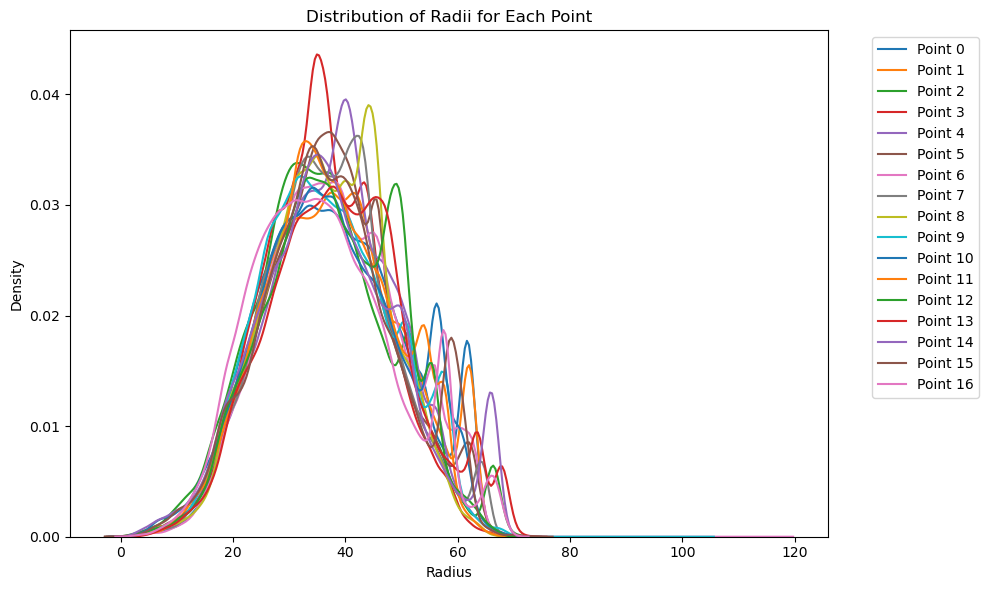

In [9]:
plt.figure(figsize=(10, 6))

# Plot KDE for each point
for i in range(all_radii.shape[1]):
    sns.kdeplot(data=all_radii[:, i], label=f'Point {i}')

plt.xlabel('Radius')
plt.ylabel('Density')
plt.title('Distribution of Radii for Each Point')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
print(all_radii.shape)
total_frame_cnt = all_radii.shape[0]

(90002, 17)


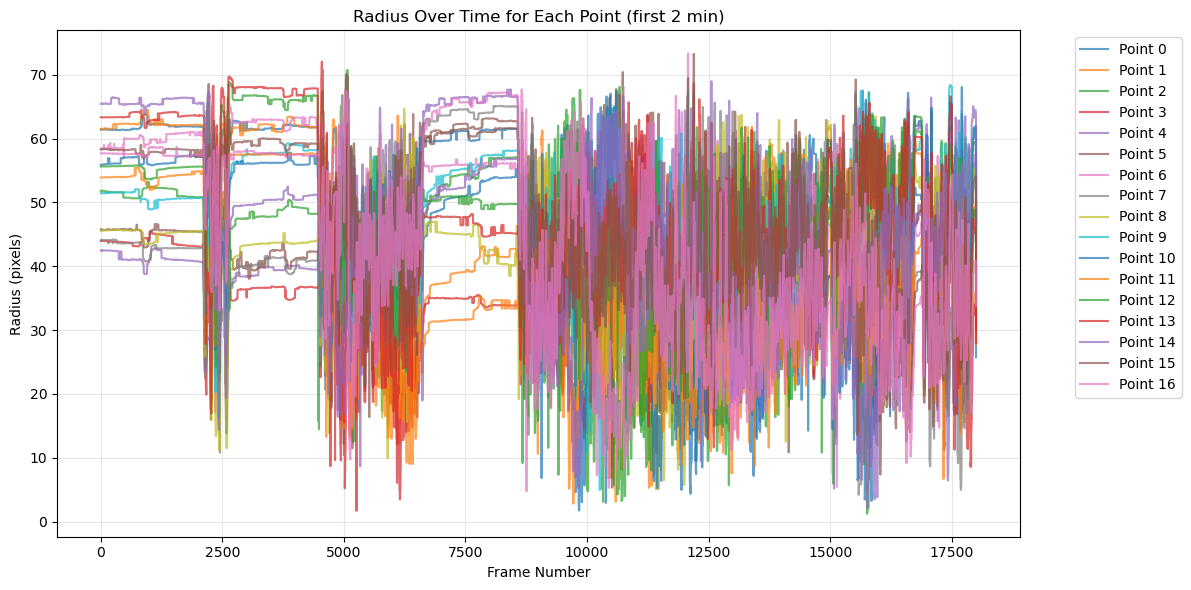

In [11]:
plt.figure(figsize=(12, 6))
x_minute = 2
first_x_min = all_radii[:int(total_frame_cnt / 10 * x_minute)]

# Plot time series for each point
for i in range(first_x_min.shape[1]):
    plt.plot(range(first_x_min.shape[0]), first_x_min[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number')
plt.ylabel('Radius (pixels)')
plt.title(f'Radius Over Time for Each Point (first {x_minute} min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### identify frames with less movement

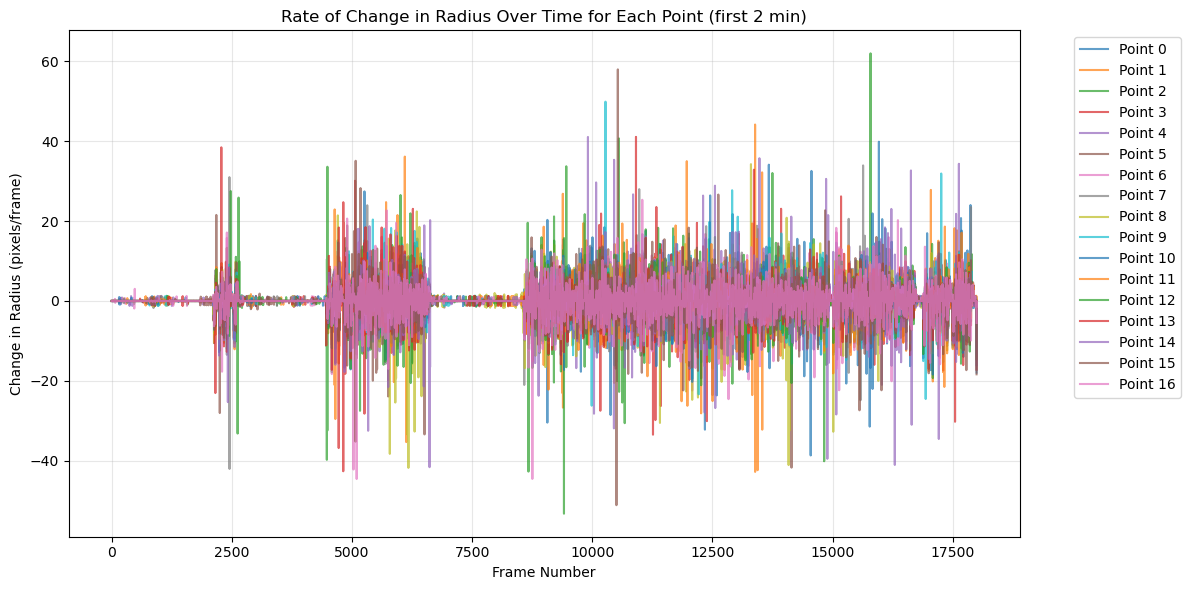

In [12]:
plt.figure(figsize=(12, 6))

# Calculate derivatives (differences between consecutive frames)
derivatives = np.diff(first_x_min, axis=0)

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number') 
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time for Each Point (first {x_minute} min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Stable ranges (frame numbers) with minimum length of 100 frames:
Frames 0 to 2126 (length: 2126)
Frames 2654 to 4462 (length: 1808)
Frames 6627 to 8570 (length: 1943)
Frames 16704 to 16888 (length: 184)


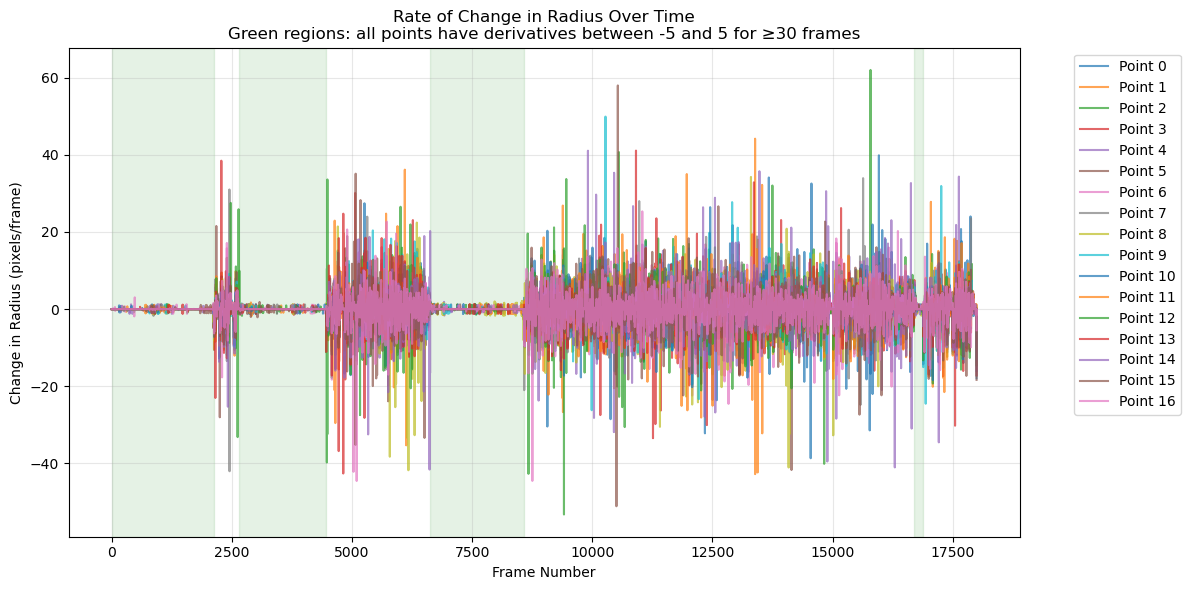

In [15]:
plt.figure(figsize=(12, 6))
min_range_length = 100

# Calculate derivatives
derivatives = np.diff(first_x_min, axis=0)

# Find ranges where all derivatives are between -5 and 5
all_stable = np.all((derivatives > -5) & (derivatives < 5), axis=1)
ranges = []
start_idx = None

# Find continuous ranges
for i in range(len(all_stable)):
    if all_stable[i] and start_idx is None:
        start_idx = i
    elif not all_stable[i] and start_idx is not None:
        if i - start_idx >= min_range_length:  # Only keep ranges at least 30 frames long
            ranges.append((start_idx, i))
        start_idx = None
        
if start_idx is not None and len(all_stable) - start_idx >= min_range_length:  # Handle case where last range extends to end
    ranges.append((start_idx, len(all_stable)))

# Print the ranges
print(f"Stable ranges (frame numbers) with minimum length of {min_range_length} frames:")
for start, end in ranges:
    print(f"Frames {start} to {end} (length: {end-start})")

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

# Add vertical bars for stable ranges
for start, end in ranges:
    plt.axvspan(start, end, color='green', alpha=0.1)

plt.xlabel('Frame Number')
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time\nGreen regions: all points have derivatives between -5 and 5 for ≥30 frames')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### filter for frames where all radius are above mean

mean_radii: [35.88887451 34.70696451 34.19926079 28.57396974 32.37398359 35.14246077
 37.28549895 33.62623162 32.6992762  37.32289639 35.42871798 30.23040408
 36.0028537  38.65460458 37.19667053 37.59074905 34.9025168 ]
Stable ranges (frame numbers) with minimum length of 100 frames and all radii above 80.0% mean:
    - Frames 0 to 2117 (length: 2117)
    - Frames 2654 to 4461 (length: 1807)
    - Frames 6745 to 8569 (length: 1824)


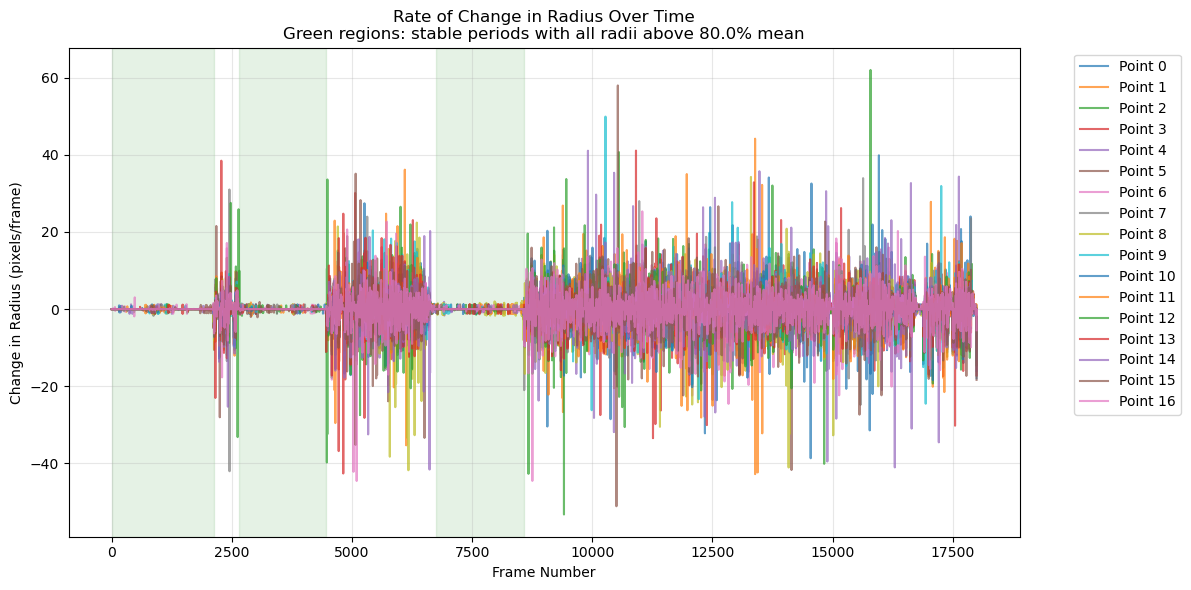

In [22]:
plt.figure(figsize=(12, 6))
min_range_length = 100

# Calculate derivatives
derivatives = np.diff(first_x_min, axis=0)

# Find ranges where all derivatives are between -5 and 5
all_stable = np.all((derivatives > -5) & (derivatives < 5), axis=1)
ranges = []
start_idx = None

# Find continuous ranges
for i in range(len(all_stable)):
    if all_stable[i] and start_idx is None:
        start_idx = i
    elif not all_stable[i] and start_idx is not None:
        if i - start_idx >= min_range_length:  # Only keep ranges at least 100 frames long
            ranges.append((start_idx, i))
        start_idx = None
        
if start_idx is not None and len(all_stable) - start_idx >= min_range_length:
    ranges.append((start_idx, len(all_stable)))

# Calculate mean radius for each point
mean_scale = 0.8
mean_radii = np.mean(first_x_min, axis=0) * mean_scale
print(f'mean_radii: {mean_radii}')
# Filter ranges to only include frames where all radii are above their means
filtered_ranges = []
for start, end in ranges:
    # For each frame in range, check if all points are above their means
    above_mean_mask = np.all(first_x_min[start:end] > mean_radii, axis=1)
    
    # Find continuous sub-ranges where all points are above mean
    sub_start_idx = None
    for i in range(len(above_mean_mask)):
        if above_mean_mask[i] and sub_start_idx is None:
            sub_start_idx = start + i
        elif (not above_mean_mask[i] or i == len(above_mean_mask)-1) and sub_start_idx is not None:
            sub_end_idx = start + i
            if sub_end_idx - sub_start_idx >= min_range_length:
                filtered_ranges.append((sub_start_idx, sub_end_idx))
            sub_start_idx = None

# Print the filtered ranges
print(f"Stable ranges (frame numbers) with minimum length of {min_range_length} frames and all radii above {mean_scale*100}% mean:")
for start, end in filtered_ranges:
    print(f"    - Frames {start} to {end} (length: {end-start})")

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

# Add vertical bars for filtered ranges
for start, end in filtered_ranges:
    plt.axvspan(start, end, color='green', alpha=0.1)

plt.xlabel('Frame Number')
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time\nGreen regions: stable periods with all radii above {mean_scale*100}% mean')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Find swapped TBs

For each frame in the filtered ranges:
- Check if the TBs are connected to the nearest neighbor 

In [26]:
# TODO: need to first have samples where TBs are swapped

In [34]:
c3_simplemax_track_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking.slp'
c3_simplemax_track = sleap.load_file(c3_simplemax_track_path)
c3_simplemax_tracked_points = get_all_tracked_points(c3_simplemax_track, reorder=True)
c3_simplemax_tracked_points.shape

all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


(827, 17, 2)

In [23]:
t1_all_tracked_points.shape

(90002, 17, 2)

In [25]:
filtered_ranges = np.array(filtered_ranges)
filtered_ranges.shape

(3, 2)

In [ ]:
for start, end in filtered_ranges:
    for frame_idx in range(start, end):
        frame_points = t1_all_tracked_points[frame_idx]
        for point_idx in range(frame_points.shape[0]):
            point = frame_points[point_idx]
            nearest_neighbor = get_nearest_neighbor(point, frame_points)
            if nearest_neighbor is None:
                print(f'TB {point_idx} is not connected to any neighbor in frame {frame_idx}')